In [128]:
%matplotlib inline

In [129]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(matplotlib.__version__)
print(pd.__version__)
print(np.__version__)


3.11.2
3.0.6
2.5.3


In [130]:
df = pd.read_csv('/content/diabetes_risk.csv')
df.head(10)

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
5,6,58,Male,Hyderabad,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,High,Low
6,7,42,Female,Hyderabad,22.5,No,Sedentary,Non-Vegetarian,NaN,NaN,7.0,10,190,7.5,140,81,95.0,High,Moderate
7,8,42,Female,Delhi,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,Middle,High
8,9,57,Male,Mumbai,20.3,Yes,Moderate,Non-Vegetarian,Current,Never,4.8,10,186,7.4,170,91,92.3,High,Moderate
9,10,44,Male,Mumbai,24.1,No,Moderate,Non-Vegetarian,Current,Occasional,6.2,8,178,7.6,150,90,102.5,High,Moderate


In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

In [132]:
df.isna().mean()

patient_id                  0.000000
age                         0.000000
gender                      0.000000
city                        0.000000
bmi                         0.000000
family_history_diabetes     0.000000
physical_activity_level     0.000000
diet_type                   0.000000
smoking_status              0.031467
alcohol_consumption         0.252533
hours_sleep_per_night       0.000000
stress_level                0.000000
fasting_blood_sugar         0.000000
hba1c_level                 0.000000
blood_pressure_systolic     0.000000
blood_pressure_diastolic    0.000000
waist_circumference_cm      0.000000
income_bracket              0.030867
diabetes_risk               0.000000
dtype: float64

In [133]:
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Unknown')

In [134]:
df = df.dropna(axis='rows')

In [135]:
print("\n", df.isna().sum().sum())


 0


In [136]:
patient_id = df.pop('patient_id').to_frame()

In [137]:
df.head(10)

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
5,58,Male,Hyderabad,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,High,Low
7,42,Female,Delhi,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,Middle,High
8,57,Male,Mumbai,20.3,Yes,Moderate,Non-Vegetarian,Current,Never,4.8,10,186,7.4,170,91,92.3,High,Moderate
9,44,Male,Mumbai,24.1,No,Moderate,Non-Vegetarian,Current,Occasional,6.2,8,178,7.6,150,90,102.5,High,Moderate
10,51,Male,Kolkata,21.5,No,Moderate,Non-Vegetarian,Never,Occasional,10.0,2,139,6.5,130,80,99.6,Middle,Low


In [138]:
df['kelompok_usia'] = pd.cut(df['age'], bins=[0, 18, 65, 100], labels=['anak', 'dewasa',
'lansia'])
df.head(10)

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,kelompok_usia
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low,dewasa
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low,dewasa
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High,dewasa
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low,dewasa
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low,dewasa
5,58,Male,Hyderabad,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,High,Low,dewasa
7,42,Female,Delhi,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,Middle,High,dewasa
8,57,Male,Mumbai,20.3,Yes,Moderate,Non-Vegetarian,Current,Never,4.8,10,186,7.4,170,91,92.3,High,Moderate,dewasa
9,44,Male,Mumbai,24.1,No,Moderate,Non-Vegetarian,Current,Occasional,6.2,8,178,7.6,150,90,102.5,High,Moderate,dewasa
10,51,Male,Kolkata,21.5,No,Moderate,Non-Vegetarian,Never,Occasional,10.0,2,139,6.5,130,80,99.6,Middle,Low,dewasa


In [139]:
from pandas.api.types import CategoricalDtype

income_bracket_level = CategoricalDtype(['Low', 'Middle', 'High'], ordered=True)
df['income_bracket'] = df['income_bracket'].astype(income_bracket_level)
df = df.sort_values(['income_bracket'], ascending=True)

df.head(10)

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,kelompok_usia
12457,45,Female,Chennai,28.4,No,Moderate,Vegan,Current,Never,7.4,8,145,6.3,156,100,109.1,Low,Low,dewasa
11926,18,Female,Nagpur,16.2,Yes,Active,Non-Vegetarian,Current,Occasional,8.3,3,133,6.0,110,78,83.5,Low,Low,anak
5809,38,Female,Jaipur,17.3,Yes,Active,Non-Vegetarian,Never,Unknown,8.0,2,167,6.9,140,80,80.9,Low,Moderate,dewasa
11922,48,Male,Lucknow,21.2,No,Moderate,Non-Vegetarian,Never,Occasional,7.9,7,175,7.2,146,90,96.7,Low,Low,dewasa
5808,23,Female,Delhi,19.6,No,Active,Non-Vegetarian,Current,Never,7.0,4,113,5.6,127,80,92.8,Low,Low,dewasa
5807,64,Other,Chennai,21.6,No,Moderate,Non-Vegetarian,Current,Never,6.5,7,210,8.5,150,83,94.5,Low,High,dewasa
11918,54,Male,Lucknow,19.6,No,Active,Non-Vegetarian,Never,Never,8.4,4,148,7.5,144,80,96.1,Low,Moderate,dewasa
11917,48,Male,Delhi,22.4,Yes,Moderate,Non-Vegetarian,Never,Occasional,5.0,7,180,6.9,140,90,105.7,Low,Low,dewasa
2935,29,Male,Patna,17.4,No,Active,Vegetarian,Never,Never,6.4,6,139,6.1,120,70,86.4,Low,Low,dewasa
2936,37,Male,Kolkata,20.5,No,Moderate,Non-Vegetarian,Current,Unknown,7.0,9,132,6.4,140,90,93.4,Low,Low,dewasa


In [140]:
from pandas.api.types import CategoricalDtype

diabetes_risk_level = CategoricalDtype(['Low', 'Moderate', 'High'], ordered=True)
df['diabetes_risk'] = df['diabetes_risk'].astype(diabetes_risk_level)
df = df.sort_values('diabetes_risk', ascending=True)

df.head(10)

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,kelompok_usia
12457,45,Female,Chennai,28.4,No,Moderate,Vegan,Current,Never,7.4,8,145,6.3,156,100,109.1,Low,Low,dewasa
3726,42,Male,Indore,24.1,No,Active,Vegetarian,Current,Never,7.5,4,144,6.0,123,86,107.3,Middle,Low,dewasa
3723,44,Male,Surat,18.0,No,Active,Non-Vegetarian,Never,Never,7.0,3,139,6.1,130,83,88.1,Middle,Low,dewasa
1812,37,Female,Kolkata,20.3,No,Active,Non-Vegetarian,Never,Never,7.0,3,111,5.7,130,80,88.3,Middle,Low,dewasa
3716,18,Male,Delhi,18.0,Yes,Active,Vegetarian,Never,Occasional,7.6,8,118,5.3,120,96,89.5,Middle,Low,anak
1934,18,Female,Delhi,19.2,No,Active,Non-Vegetarian,Never,Occasional,7.5,8,153,6.3,120,72,88.8,Middle,Low,anak
1818,65,Male,Mumbai,19.8,No,Moderate,Non-Vegetarian,Never,Occasional,6.0,5,154,6.7,140,96,94.8,Middle,Low,dewasa
1931,53,Female,Ahmedabad,20.5,No,Moderate,Non-Vegetarian,Former,Unknown,7.0,1,182,6.9,136,82,90.4,Middle,Low,dewasa
3732,35,Female,Delhi,20.3,Yes,Active,Non-Vegetarian,Never,Never,7.0,7,151,5.7,137,80,94.5,Middle,Low,dewasa
3476,46,Male,Kanpur,23.2,No,Sedentary,Non-Vegetarian,Current,Never,10.0,5,162,6.5,160,80,102.5,Middle,Low,dewasa


In [141]:
rerata_bmi = df['bmi'].mean()
rerata_bmi

np.float64(23.049751279135872)

In [142]:
df.query('bmi > @rerata_bmi')

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,kelompok_usia
12457,45,Female,Chennai,28.4,No,Moderate,Vegan,Current,Never,7.4,8,145,6.3,156,100,109.1,Low,Low,dewasa
3726,42,Male,Indore,24.1,No,Active,Vegetarian,Current,Never,7.5,4,144,6.0,123,86,107.3,Middle,Low,dewasa
3476,46,Male,Kanpur,23.2,No,Sedentary,Non-Vegetarian,Current,Never,10.0,5,162,6.5,160,80,102.5,Middle,Low,dewasa
3746,24,Male,Delhi,27.3,No,Moderate,Non-Vegetarian,Never,Never,7.0,6,188,7.5,130,78,109.6,Middle,Low,dewasa
3768,39,Female,Hyderabad,30.0,No,Moderate,Vegetarian,Former,Never,8.4,3,99,5.4,148,90,114.5,Middle,Low,dewasa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13336,49,Male,Nagpur,27.7,No,Sedentary,Vegetarian,Never,Occasional,7.0,6,215,7.7,132,90,118.1,Middle,High,dewasa
12100,36,Female,Ahmedabad,31.1,Yes,Moderate,Vegetarian,Never,Occasional,7.0,5,215,8.2,144,102,111.3,Middle,High,dewasa
62,36,Male,Delhi,23.1,No,Moderate,Non-Vegetarian,Never,Never,6.0,7,219,8.1,141,88,102.6,High,High,dewasa
12047,53,Female,Delhi,26.5,No,Moderate,Vegetarian,Never,Unknown,7.5,5,205,6.8,150,97,107.9,Middle,High,dewasa


In [143]:
agregasi_risiko= df.groupby('diabetes_risk').agg(
    jumlah_pasien=('age', 'count'),
    rata_rata_bmi=('bmi', 'mean'),
    max_hba1c=('hba1c_level', 'max'),
    min_hba1c=('hba1c_level', 'min'),
    rata_rata_gula_darah=('fasting_blood_sugar', 'mean')
)
agregasi_risiko

,jumlah_pasien,rata_rata_bmi,max_hba1c,min_hba1c,rata_rata_gula_darah
diabetes_risk,,,,,
Low,8462,22.129638,8.6,4.8,148.251123
Moderate,3514,24.032413,8.9,5.8,183.287706
High,2096,25.116985,12.4,6.4,226.599237


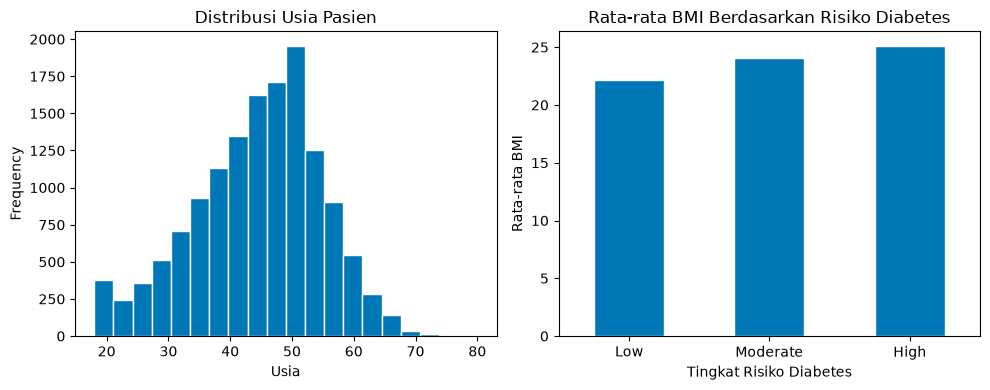

In [144]:
plt.rcParams['figure.figsize'] = (10, 4)

plt.subplot(1, 2, 1)
df['age'].plot(kind='hist', bins=20, color='#0077B6', edgecolor='white')
plt.title('Distribusi Usia Pasien')
plt.xlabel('Usia')

plt.subplot(1, 2, 2)
agregasi_risiko['rata_rata_bmi'].plot(kind='bar', color='#0077B6', edgecolor='white')
plt.title('Rata-rata BMI Berdasarkan Risiko Diabetes')
plt.xlabel('Tingkat Risiko Diabetes')
plt.ylabel('Rata-rata BMI')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

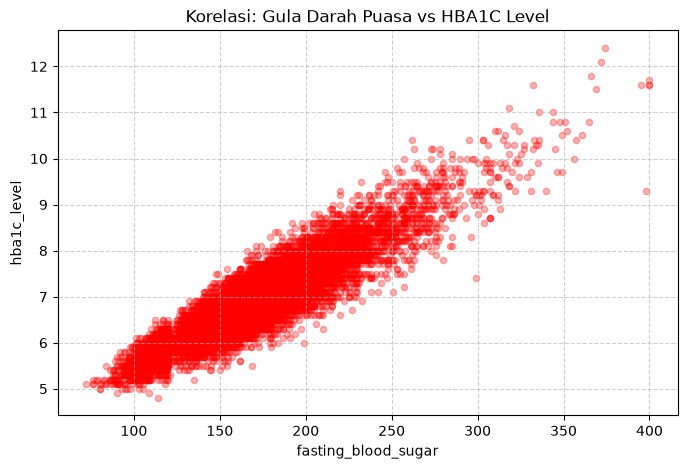

In [145]:
df.plot(
    x='fasting_blood_sugar',
    y='hba1c_level',
    kind='scatter',
    color='red',
    alpha=0.3,
    title='Korelasi: Gula Darah Puasa vs HBA1C Level',
    figsize=(8, 5)
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()